# Week 11 - Part 3 Matplotlib

This week we will be covering the data visualisation package Matplotlib. This is a basic, but very powerful, plotting open-source library in Python. This is generally the recommended starter package for visualisations in Python as it is very simple and well documented, but it is worth noting there are many other powerful plotting packages including:
- Seaborn (layered on top of Matplotlib, especially useful for working with Pandas dataframes)
- plotnine or Altair (both very useful packages similar to plotting packages available in R)
- Plotly (great for interative and complex plots)
- manim (if you're familiar with 3Blue1Brown this is how their visualisations are made!)

If you have interest in learning data visualisations to a high level I'd recommend looking into these packages to find those best suited to you. Please reach out if you need any assistance with learning about any of those listed above (or let me know if you find any other useful ones!).

## 0 - Setup in Pandas
This section can be skipped as setup, or looked through for interest in expanding your Pandas knowledge. We are using the same example data as last week, but making some adjustments to provide more interesting visualisations.

In [1]:
# Import numpy and pandas for data generation and manipulation
import numpy as np
import pandas as pd

In [2]:
# Import in example data
df = pd.read_csv('example_data.csv', skiprows=(1),names=['DateTime', 'ActivePower', 'WindSpeed', 'TheoreticalPower', 'WindDir', 'WindSD'])

In [3]:
#--------------------------------------------------
# Extract monthly averages from the data
#--------------------------------------------------

# Convert datetime column to pandas datetime format
df['DateTime'] = pd.to_datetime(df.DateTime, dayfirst=True, errors='coerce')
# Access the month attribute from each date in the datetime column and save as a new column
df['Month'] = [date.month for date in df.DateTime]


# Group by month, compute mean and standard deviation
monthly_stats = df.groupby("Month")["WindSpeed"].agg(["mean", "std"])
# Save values for months, mean speeds and standard errors from the computed dataframe
months = monthly_stats.index
avg_speeds = monthly_stats["mean"].values
errors = monthly_stats["std"].values  # error bars = standard deviation

In [4]:
#---------------------------------------------------------------
# Split data into two fictitious sites, one with higher average
#-------------------------------------------------------------------

# Randomly shuffle the data
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Sort by wind speed descending
df_sorted = df_shuffled.sort_values("WindSpeed", ascending=False).reset_index(drop=True)

# Assign higher half to Site A, lower half to Site B
mid = len(df_sorted) // 2
df_sorted["site"] = ["Site A"] * mid + ["Site B"] * (len(df_sorted) - mid)

# Compute average wind speed per month per site
monthly_site_avg = df_sorted.groupby(["Month", "site"])["WindSpeed"].mean().unstack(fill_value=0)

# Extract data for plotting
month_positions = np.arange(len(months))  # positions for months
width = 0.35  # width of each bar

## 1 - Getting started
## 1.0 Import package
We use the same importing method as before, using the most common nickname plt.

In [5]:
import matplotlib.pyplot as plt

## 1.1 - Simple Lineplot
Let's start of with a very simple example - we'll first generate x and y data using NumPy, before using the plt.plot() function, which takes x and y arrays or lists as arguments to plot a line-plot of (x,y) pairs.

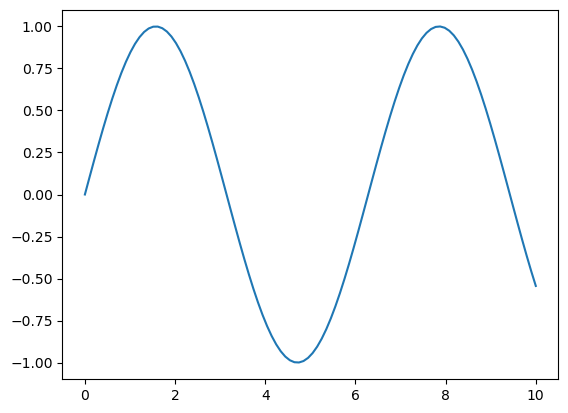

In [22]:
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
plt.plot(x,y1)

## 1.2 - Customisation
Let's now make a more complex version with customisation. Firstly, lets look at the arguments we can input to plt.plot().

The line style and color can be specified as a string with the format of a single letter specifying color followed by a character specifying the linestyle e.g. 'b-' below refers to the color blue and a straight single line. We may also increase or decrease our linewidth through the argument lw. Additional arguments for this plot not shown here may be found in the [docs](https://matplotlib.org/2.1.0/api/_as_gen/matplotlib.pyplot.plot.html).

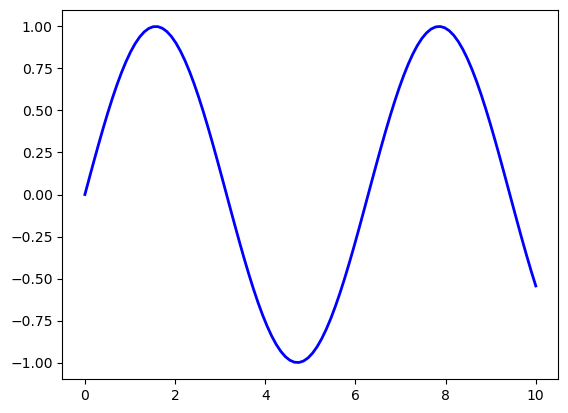

In [7]:
plt.plot(x, y1, 'b-', lw=2)

See below the full range of colors and styles. Note that the tri markers look like wind turbines which can make for great wind energy plots ;)
|Letter|Color|
|---|---|
|b|blue|
|g|green|
|r|red|
|c|cyan|
|m|magenta|
|y|yellow|
|k|black|
|w|white|

|Character|Line/Marker Style|
|---|---|
|-|solid line style|
|--|dashed line style|
|-.|dash-dot line style|
|:|dotted line style
|.|point marker|
|,|pixel marker|
|o|circle marker|
|v|triangle_down marker|
|^|triangle_up marker|
|<|triangle_left marker|
|>|triangle_right marker|
|1|tri_down marker|
|2|tri_up marker|
|3|tri_left marker|
|4|tri_right marker|
|s|square marker|
|p|pentagon marker|
|*|star marker|
|h|hexagon1 marker|
|H|hexagon2 marker|
|+|plus marker|
|x|x marker|
|D|diamond marker|
|d|thin_diamond marker|
|_|hline marker|

#### Excercise 1.2.1

Plot x against y2 using a dotted line style in the color red with a doubled linewidth.

We can also put in more than one dataset within our plot function by specifying the second data arguments in the same order directly after the arguments for the first data pair.

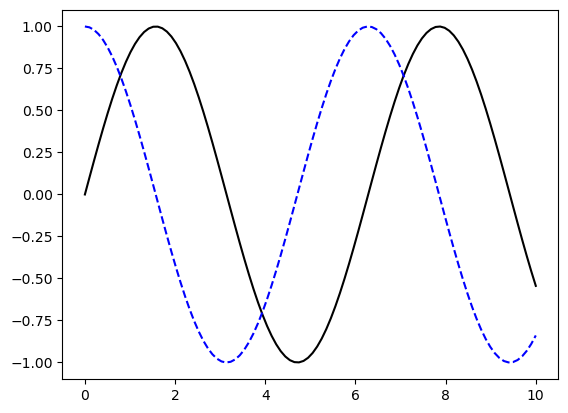

In [23]:
plt.plot(x, y1,'k-', x, y2, 'b--')

The problem with this however is that those seeing the plot might not know which data is which. We can specify this by instead plotting them separately and providing them with a label in the arguments. We may then use the legend() function to add a key specifying which style refers to which data.

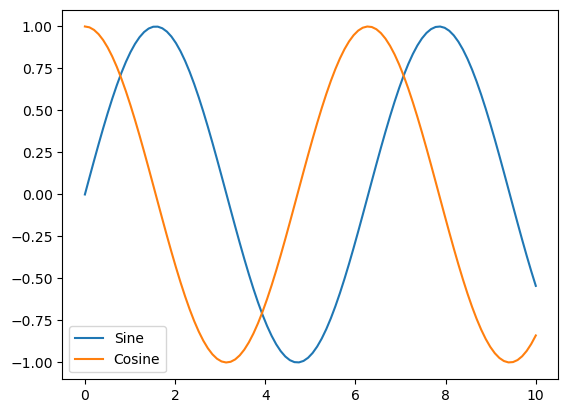

In [9]:
plt.plot(x,y1, label='Sine')
plt.plot(x, y2, label='Cosine')
plt.legend()

As well as legend, there are many other functions which can help us further customise our plot.

Text(7.57, 0.88, 'Peak')

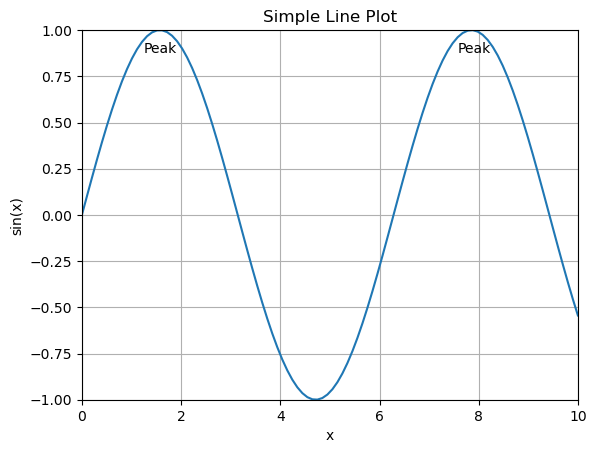

In [10]:
plt.plot(x, y1)
plt.xlabel("x") # Add label to the x-axis
plt.ylabel("sin(x)") # Add label to the y-axis
plt.xlim(0,10) # Limit the x axis between a lower and upper bound
plt.ylim(-1,1) # Limit the y axis between a lower and upper bound
plt.grid() # Add a grid with lines from each 'tick' on the respective axis
plt.title("Simple Line Plot") # Add a plot title

# Add annotations to given (x,y) coordinates
plt.annotate('Peak',(1.25,0.88))
plt.annotate('Peak',(7.57,0.88))

#### Exercise 1.2.2
Add a label to the Trough at coordinate (4.22,-0.88).

# 2 - Figure and Axes
Matplotlib is built around figures (the overall container) and axes (the plot area inside the figure). One figure may have one or multiple axes, with each axis having its own features such as x-axis, y-axis, title etc. We may think of a figure as a piece of paper with axes being plots drawn on that paper. We may add features to the paper itself such as adding a full page title, but may also have individual customization of each plot we draw on it.

Let's first create a single figure and axis. We use the function plt.subplots(), which takes number of plots to be one unless otherwise specified. It additionally takes the argument of figsize which specifies x (width) and y (height) dimensions in inches. In general these dimensions should have a 1.5:1 ratio, but this varies plot to plot.

Once we have defined our figure and axis, we may plot on our axis using its own method plot() rather than the broader plt.plot().

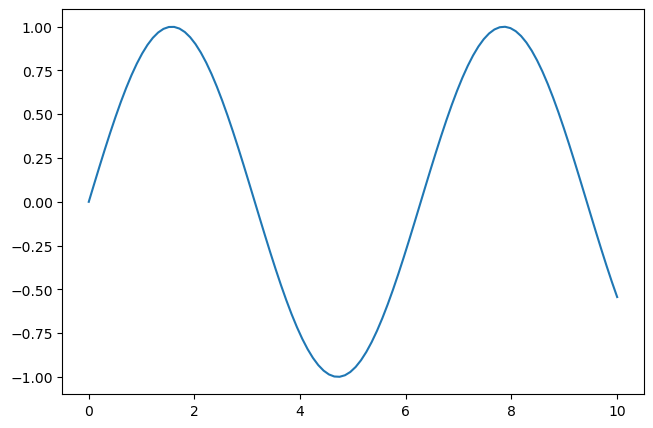

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 5))  # figsize is in inches (width, height)
ax.plot(x, y1)

You can use this same function to create multiple axes within the same function by specifying rows, cols as arguments prior to the figsize.
To plot we then access our axes using the same principle as accessing from an array specifying first the row then the column axes[row, col]. Note that some of the customisation functions have different names than the ones inbuilt and accessed via the core package.

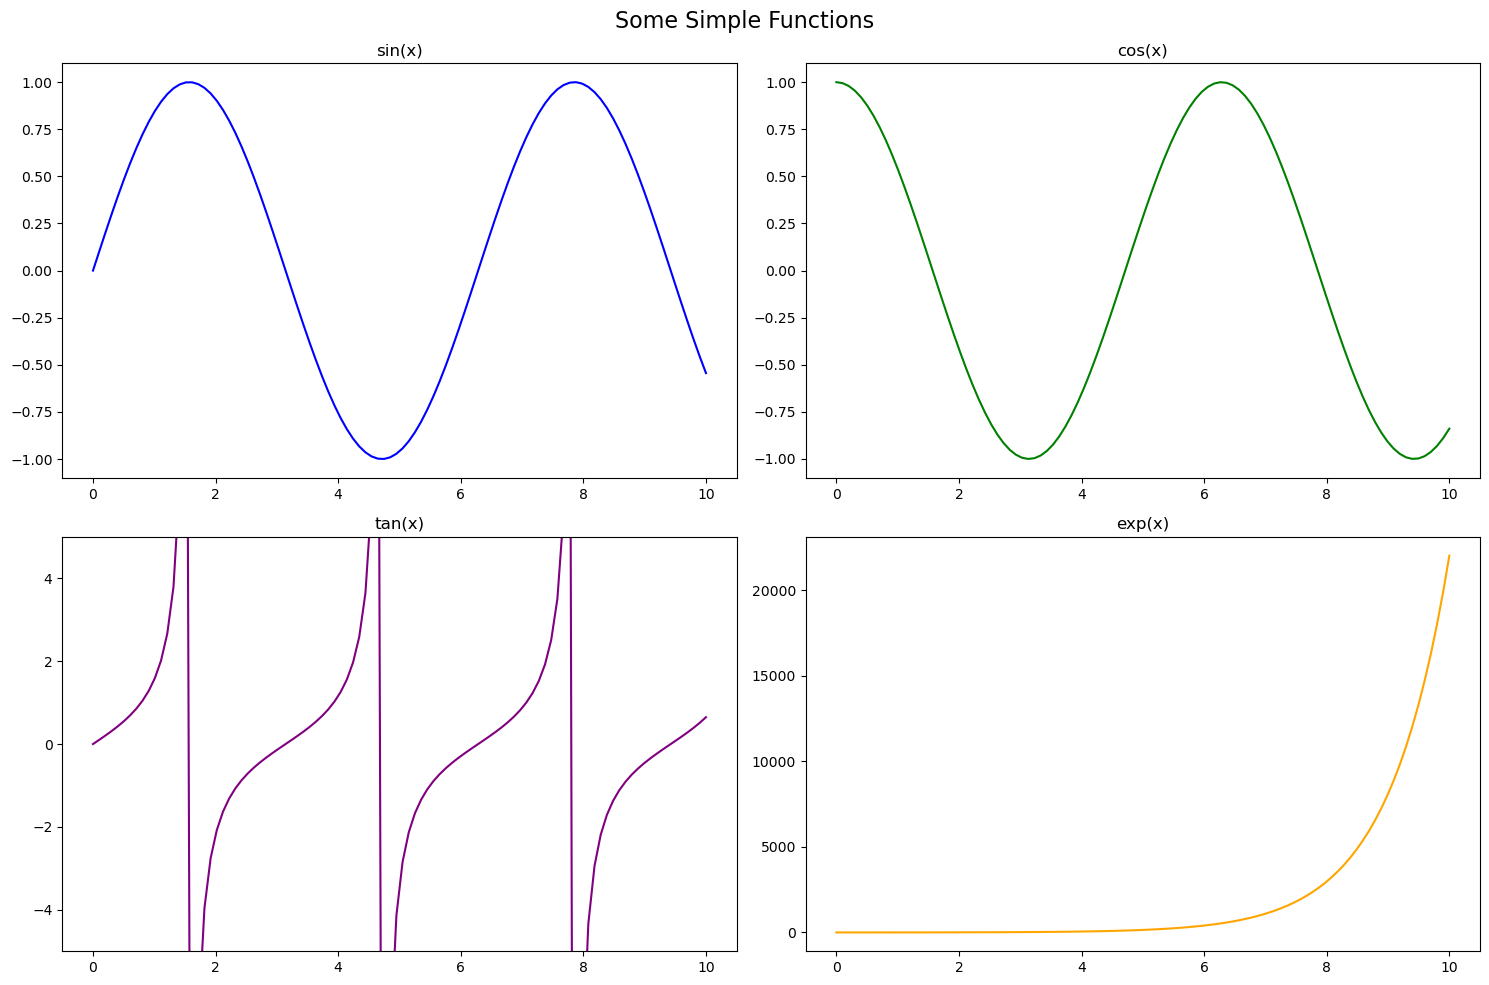

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))  # Creates a 2x2 grid of axes

y3 = np.tan(x)
y4 = np.exp(x)

axes[0, 0].plot(x, y1, color="blue")
axes[0, 0].set_title("sin(x)")

axes[0, 1].plot(x, np.cos(x), color="green")
axes[0, 1].set_title("cos(x)")

axes[1, 0].plot(x, y3, color="purple")
axes[1, 0].set_title("tan(x)")
axes[1, 0].set_ylim(-5, 5) 

axes[1, 1].plot(x, y4, color="orange")
axes[1, 1].set_title("exp(x)")

fig.suptitle('Some Simple Functions', fontsize=16)
plt.tight_layout()  # prevent overlap of titles/labels
plt.show()

Since it can be a bit confusing to remember both the plt functions and the ax methods it is sometimes easier instead to specify the axis we are using and plot as normal. We do this using plt.sca() specifying axes[row, col] as an argument. 

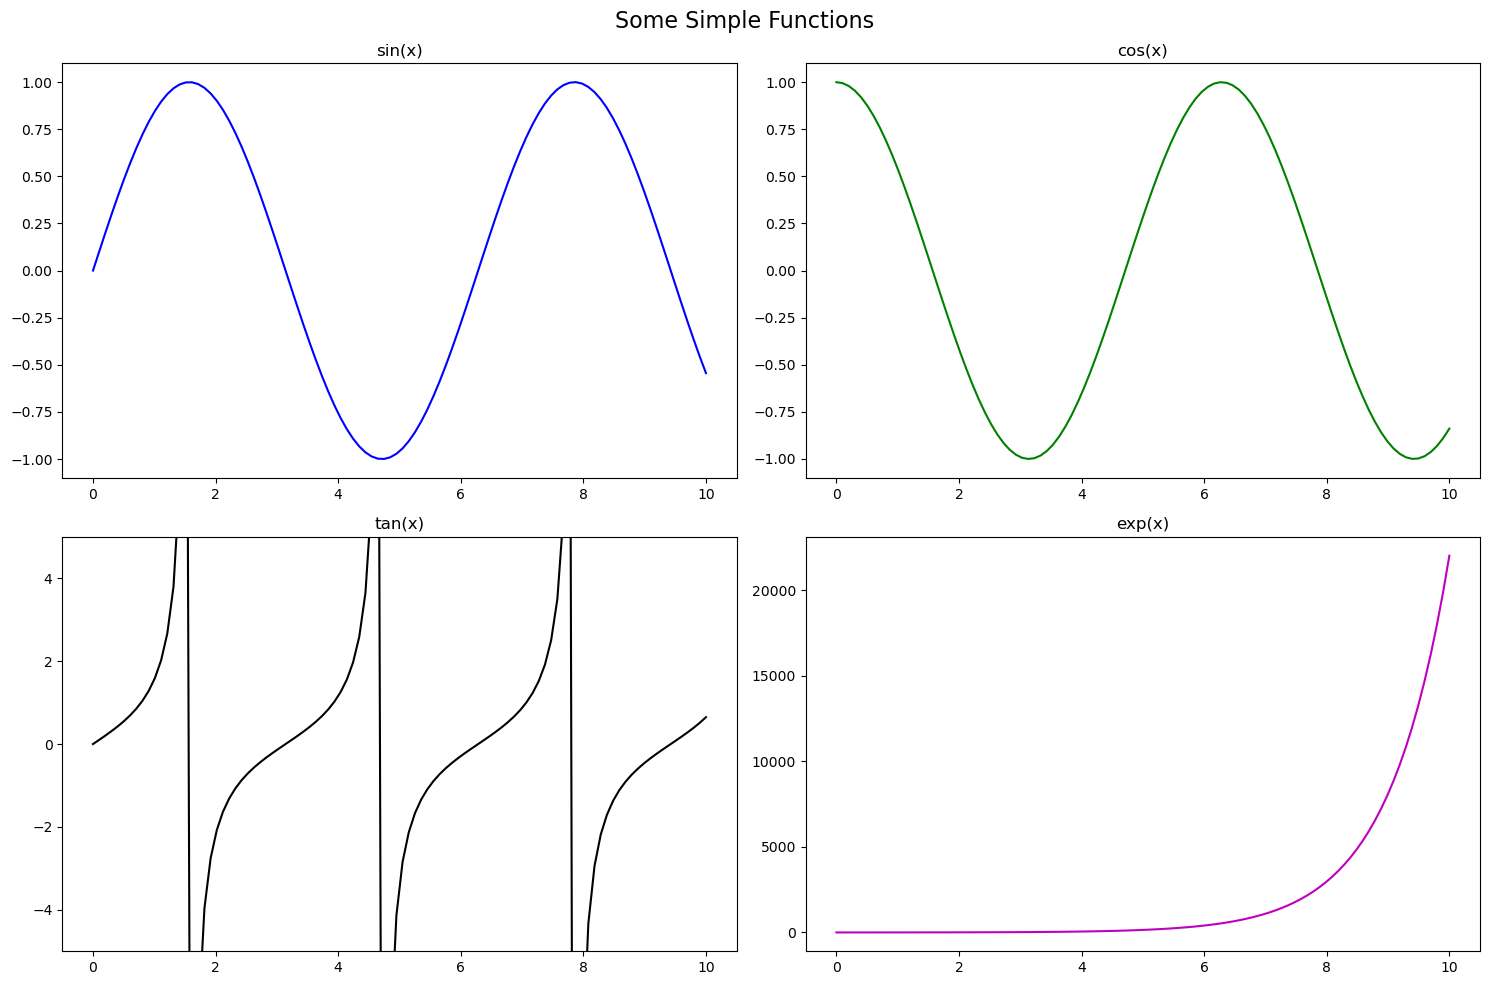

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10)) 

plt.sca(axes[0,0])
plt.plot(x, y1, 'b-')
plt.title("sin(x)")

plt.sca(axes[0,1])
plt.plot(x, np.cos(x), 'g-')
plt.title("cos(x)")

plt.sca(axes[1,0])
plt.plot(x, y3, 'k-')
plt.title("tan(x)")
plt.ylim(-5, 5) 

plt.sca(axes[1,1])
plt.plot(x, y4, 'm-')
plt.title("exp(x)")

fig.suptitle('Some Simple Functions', fontsize=16)
plt.tight_layout() 
plt.show()

#### Exercise 2.1
Create a 1x3 set of subplots plotting sin(x), cos(x) and tan(x) respectively. Plot each with a different color and linestyle of your choice.

When looking at comparative plots it is sometimes helpful to share an x or y axes using the sharex and sharey arguments within the subplots function.

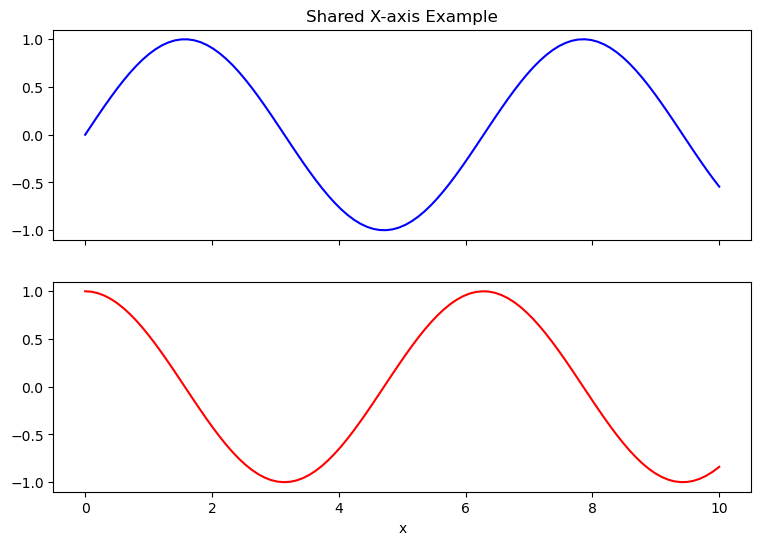

In [14]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 6))

axes[0].plot(x, y1, color="blue")
axes[0].set_title("Shared X-axis Example")

axes[1].plot(x, y2, color="red")
axes[1].set_xlabel("x")

plt.show()

#### Exercise 2.2
Recreate the above plots instead with 2 columns and a single row, with a shared y axis.

The layout and spacing between subplots may be manipulated using the subplots_adjust() function. You can specify:
- hspace (height of the padding between subplots, as a fraction of the average Axes height)
- wspace (width of the padding between subplots, as a fraction of the average Axes width)
- left (position of the left edge of the subplots, as a fraction of the figure width)
- bottom (position of the bottom edge of the subplots, as a fraction of the figure height)
- right (position of the right edge of the subplots, as a fraction of the figure width)
- top (position of the top edge of the subplots, as a fraction of the figure height)
  
The image below demonstrates these arguments. Please see the original in the [docs](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots_adjust.html).

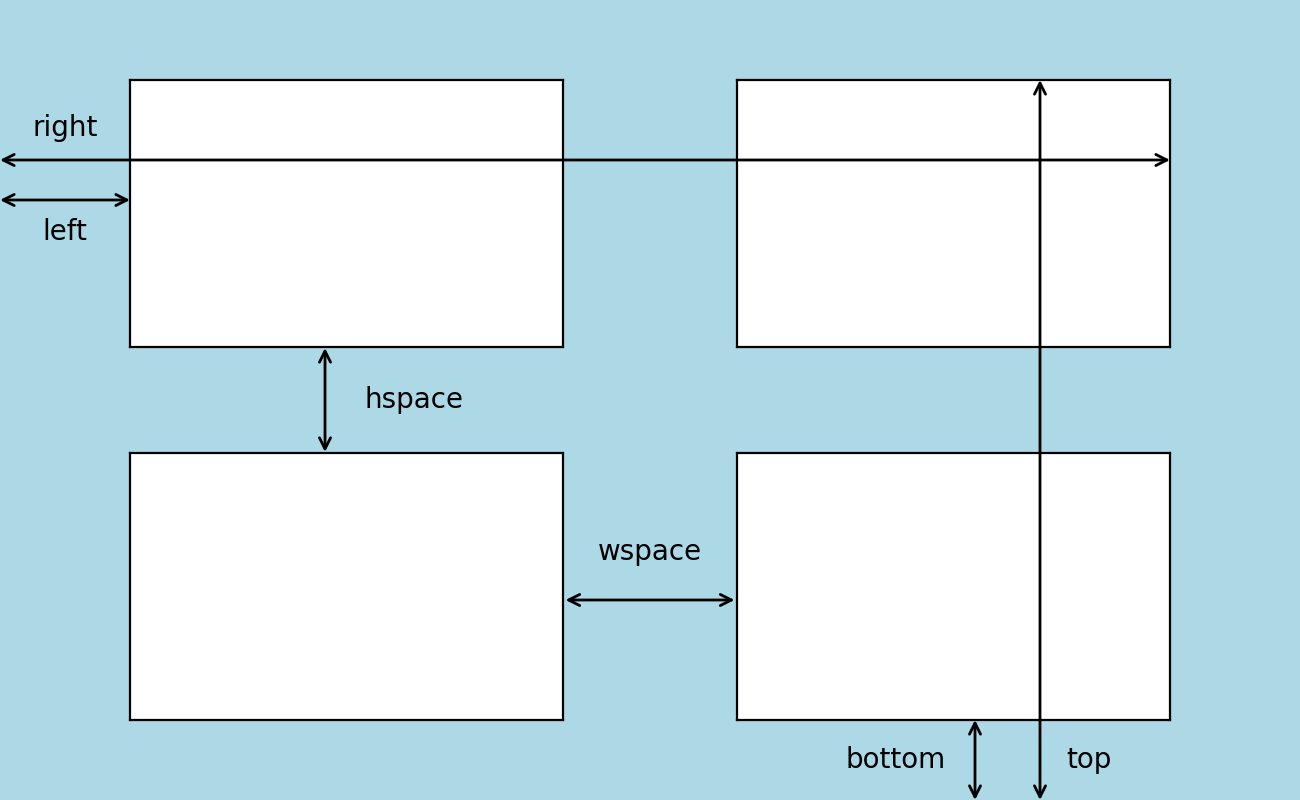

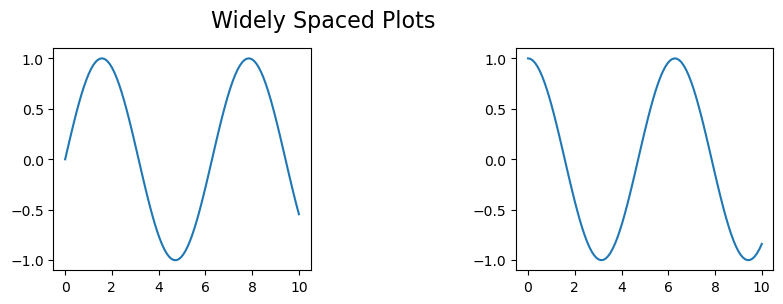

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9,3))

axes[0].plot(x, y1)
axes[1].plot(x, y2)

fig.suptitle("Widely Spaced Plots", fontsize=16)
plt.subplots_adjust(top=0.85, wspace=0.8, left=0.2, right=1)
plt.show()

#### Exercise 2.3
Recreate the above plot with 2 rows and a single column, and adjust the spacing using the hspace, bottom and top arguments in line with the ratios chosen for the original plot.

## 3 - Other Common Plots
### 3.1 Barcharts
Bar charts can help us understand and compare categories within our data. Let's look at how wind speed varies monthly within our data. In section 0 we grouped our dataframe by month, created a new dataframe of average monthly windspeeds, and extracted the months and average speeds as lists from this data. We now plot them using plt.bar() specifying the x axis values and heights (or y axis values).

<BarContainer object of 12 artists>

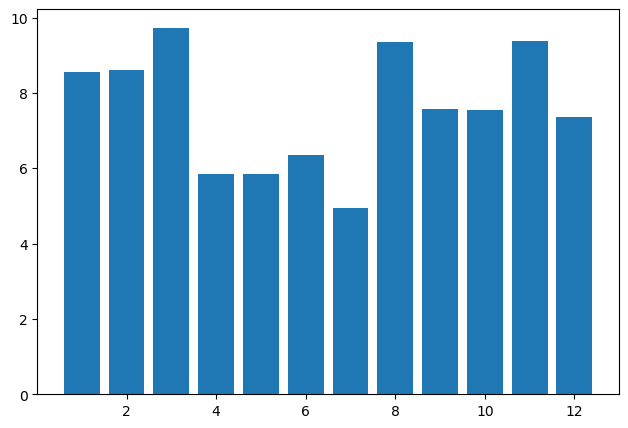

In [25]:
plt.figure(figsize=(7.5, 5))
plt.bar(x=months, height=avg_speeds)

We can add customisations such as color (purple is always a good go-to for plots at Nadara!) and edgecolor. The color arguments are optional customisations.
We can also add error bars using the yerr argument to specify a list of associated standard errors, and can add an argument capsize to specify the length of the error bar caplines.

<BarContainer object of 12 artists>

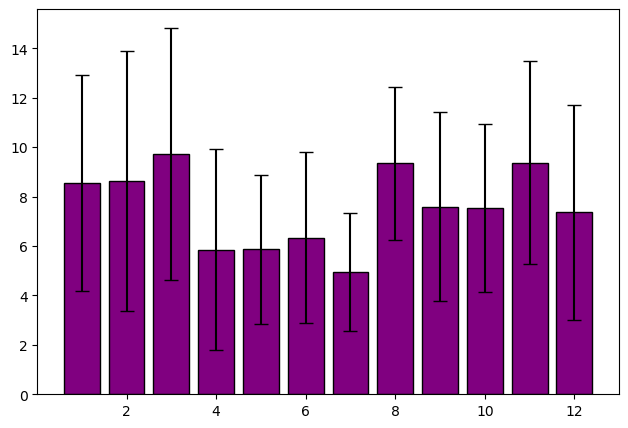

In [26]:
plt.figure(figsize=(7.5, 5)) 
plt.bar(x=months, height=avg_speeds, yerr=errors, capsize=5,color="purple", edgecolor="black")

#### Excercise 1.1
1. Change the base color and edgecolor arguments to light blue and dark blue respectively - you can see the full range of named colors in the docs [here](https://matplotlib.org/stable/gallery/color/named_colors.html).
2. Double the x and y dimensions of the above plot
3. Add a title
4. Add x (month) and y (wind speed) labels including units for the y label.

We may also create grouped barcharts to compare factors. Section 0 split the data into 2 fictitious sites, we may now compare the average monthly windspeed at both.

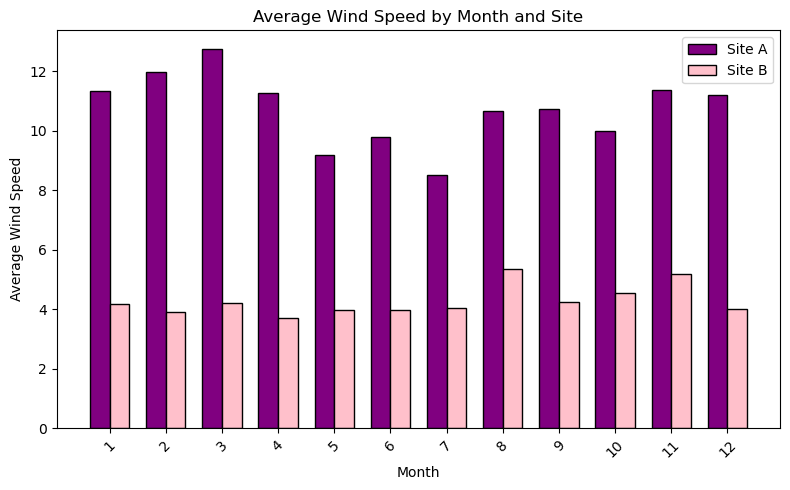

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(month_positions - width/2, monthly_site_avg["Site A"], width, label="Site A", color="purple", edgecolor="black")
plt.bar(month_positions + width/2, monthly_site_avg["Site B"], width, label="Site B", color="pink", edgecolor="black")

plt.title("Average Wind Speed by Month and Site")
plt.xlabel("Month")
plt.ylabel("Average Wind Speed")
plt.xticks(month_positions, months, rotation=45) # Alters the category labels on x-axis and rotates the labels 45 degrees
plt.legend()
plt.tight_layout()

## 3.2 - Histograms
A histogram is a chart that allows you to see the frequencies of groups of values within the data. With continuous data such as wind speed, we split the data into bins (the number of which may be specified as an argument). The width of the bin is the range in values divided by the number of bins. For example if our minimum value was 0, our maximum was 100 and the number of bins specified was 10 then we would have bins of 0-10, 10-20, 20-30 etc. The frequency is then the number of data points falling within that bin. This gives a good idea of the distribution of our data. For wind speed we expect it to be roughly Weibull shaped (please see the statistics tutorials to learn more about this).

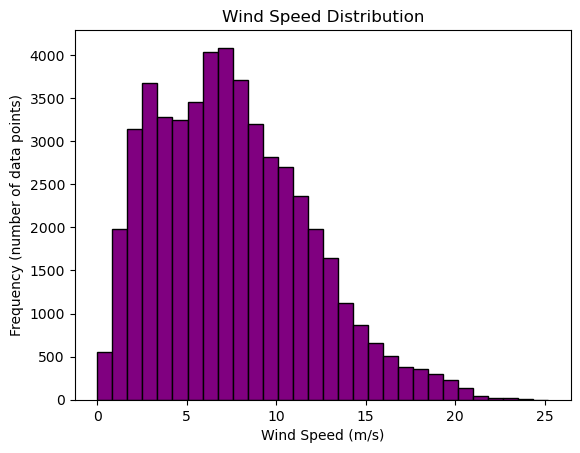

In [30]:
plt.hist(df.WindSpeed, bins=30, color="purple", edgecolor="black")
plt.title("Wind Speed Distribution")
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Frequency (number of data points)')
plt.show()

## 3.3 - Scatterplots
Scatter plots place a marker at the coordinate of every (x,y) data-pair. In section 0 we ordered our data to allow us to plot in increasing order of Wind Speed. To plot a scatterplot we use the plt.scatter() function, and can specify the size of the marker using the argument s, and color using argument c.

Text(0, 0.5, 'Active Power (kW)')

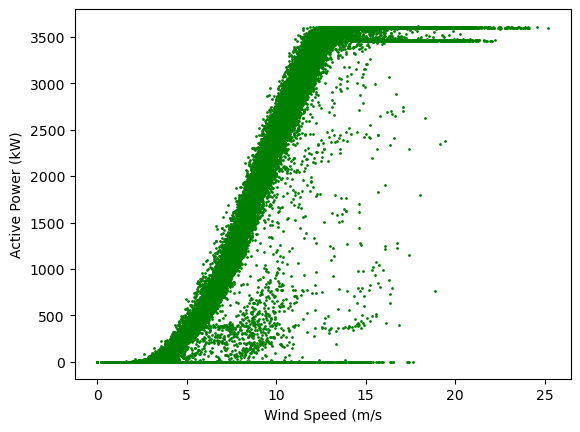

In [20]:
plt.scatter(df_sorted.WindSpeed, df_sorted.ActivePower, s=1, c='g')
plt.xlabel('Wind Speed (m/s')
plt.ylabel('Active Power (kW)')

## 4 - Exporting plots
Plots can be exported through the savefig() function. The filename (including path if saving to a specific location) is the only necessary argument, although more optional parameters can be seen [here](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html). The below code should save the image to the folder you are working in.

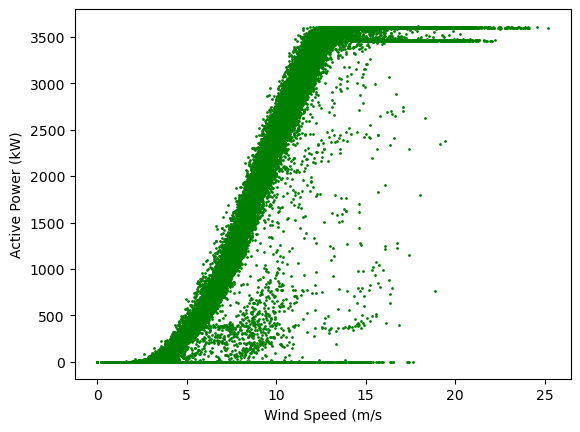

In [21]:
plt.scatter(df_sorted.WindSpeed, df_sorted.ActivePower, s=1, c='g')
plt.xlabel('Wind Speed (m/s')
plt.ylabel('Active Power (kW)')
plt.savefig('Scatterplot.png')

There are many more plot types and features available within Matplotlib and I advise anyone interested to look more fully through the [docs](https://matplotlib.org/), although we will build up to more advanced plotting techniques as we progress through the machine learning side of the course.